# CELL 1 — Load preprocessed HDF5 data

In [ ]:
import os
PROJECT_ROOT = os.path.dirname(os.path.dirname(os.path.abspath(__file__))) if "__file__" in globals() else os.path.dirname(os.getcwd())
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, "artifacts")

print("Artifacts directory:", ARTIFACTS_DIR)
print("Contents:", os.listdir(ARTIFACTS_DIR))


Artifacts directory: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts
Contents: ['1_class_distribution.png', '2_image_dimensions.png', '3_aspect_ratio.png', '4_file_size.png', '5_color_stats.png', '6_sample_grid.png', 'best_fine_tuned_model.json', 'EfficientNetB0_best.h5', 'EfficientNetB0_fine_tuned.h5', 'fine_tuning_comparison.csv', 'fine_tuning_comparison.png', 'fine_tuning_history.png', 'imagenet_class_index.json', 'MobileNetV2_best.h5', 'MobileNetV2_fine_tuned.h5', 'MobileNetV2_fine_tuned_confusion.png', 'mobilenet_v2_imagenet.tflite', 'ResNet50_best.h5', 'ResNet50_fine_tuned.h5', 'shap_EfficientNetB0.png', 'shap_EfficientNetB0_correct.png', 'shap_EfficientNetB0_correct1.png', 'shap_EfficientNetB0_correct2.png', 'shap_EfficientNetB0_correct3.png', 'shap_EfficientNetB0_incorrect.png', 'shap_EfficientNetB0_incorrect1.png', 'shap_EfficientNetB0_incorrect2.png', 'shap_EfficientNetB0_incorrect3.png', 'shap_EfficientNetB0

In [7]:
# Cell 1 — Load preprocessed HDF5 data
import os
import h5py
import numpy as np

# Define paths (notebook is inside "notebooks/", so go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
ARTIFACTS_DIR = os.path.join(PROJECT_ROOT, "artifacts")
H5_PATH = os.path.join(ARTIFACTS_DIR, "wildlife_data.h5")

# Load datasets from HDF5
with h5py.File(H5_PATH, "r") as f:
    X_train = f["X_train"][:]
    y_train = f["y_train"][:]
    X_val   = f["X_val"][:]
    y_val   = f["y_val"][:]
    X_test  = f["X_test"][:]
    y_test  = f["y_test"][:]
    classes = [c.decode("utf-8") if isinstance(c, bytes) else str(c) for c in f["classes"][:]]

print("Loaded HDF5 data successfully")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print("Classes:", classes)


Loaded HDF5 data successfully
Train: (1052, 224, 224, 3), Val: (226, 224, 224, 3), Test: (226, 224, 224, 3)
Classes: ['buffalo', 'elephant', 'rhino', 'zebra']


# CELL 2 — Prepare test set arrays

In [ ]:
X_test_all = X_test

# Handle labels: detect one-hot vs integer
if y_test.ndim > 1 and y_test.shape[1] > 1:
    # One-hot encoded → convert to class indices
    y_test_all = np.argmax(y_test, axis=1)
else:
    # Already integers → flatten to 1D
    y_test_all = y_test.astype(int).ravel()

# Sanity check
print(f"Test set: {X_test_all.shape} | Labels distribution: {np.bincount(y_test_all)}")


Test set: (226, 224, 224, 3) | Labels distribution: [57 56 57 56]


# CELL 3 — Core SHAP helper functions

In [12]:
# Cell 3 — Core SHAP helper functions
import shap   # only new import needed here

def build_background(X_train, n=100):
    """
    Collect n training images to use as the SHAP reference baseline.
    """
    idx = np.random.choice(len(X_train), n, replace=False)
    return X_train[idx]

def run_shap_cnn(model, background, images):
    """
    Run SHAP GradientExplainer on a CNN model.
    Returns SHAP values as a NumPy array.
    """
    explainer   = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(images)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    return np.array(shap_values)

print("Helper functions defined.")



Helper functions defined.


# CELL 4 — SECTION A: Standard pixel heatmaps 

In [13]:
# Cell 4 — Prepare SHAP background and sample images
import numpy as np

# Build SHAP background from training set
background = build_background(X_train, n=100)

# Select a few test samples for visualization
sample_imgs = X_test_all[:3]   # first 3 test images
sample_labels = y_test_all[:3]

print("Background shape:", background.shape)
print("Sample images shape:", sample_imgs.shape)
print("Sample labels:", sample_labels)



Background shape: (100, 224, 224, 3)
Sample images shape: (3, 224, 224, 3)
Sample labels: [1 3 3]


In [15]:
# Define model paths dictionary
MODELS = {
    "MobileNetV2": os.path.join(ARTIFACTS_DIR, "MobileNetV2_best.h5"),
    "ResNet50": os.path.join(ARTIFACTS_DIR, "ResNet50_best.h5"),
    "EfficientNetB0": os.path.join(ARTIFACTS_DIR, "EfficientNetB0_best.h5"),
}

# Sanity check
for name, path in MODELS.items():
    print(f"{name}: {'FOUND' if os.path.exists(path) else 'MISSING'}")


MobileNetV2: FOUND
ResNet50: FOUND
EfficientNetB0: FOUND


# CELL 5 — SECTION B: Correct vs incorrect predictions

In [16]:
# Cell 5 — SHAP analysis for correct vs incorrect predictions
import matplotlib.pyplot as plt
import tensorflow as tf

N_CORRECT   = 3   # examples to show from correctly classified
N_INCORRECT = 3   # examples to show from incorrectly classified

for model_name, model_path in MODELS.items():
    if not os.path.exists(model_path):
        print(f"[SKIP] {model_name}: {model_path} not found")
        continue

    print(f"\n[{model_name}] Correct vs incorrect analysis...")
    model  = tf.keras.models.load_model(model_path)
    raw_preds = model.predict(X_test_all, verbose=0)
    tf.keras.backend.clear_session()

    # Handle binary vs multi-class outputs
    if raw_preds.ndim == 2 and raw_preds.shape[1] == 1:
        preds = (raw_preds.ravel() > 0.5).astype(int)
    else:
        preds = np.argmax(raw_preds, axis=1)

    correct_idx   = np.where(preds == y_test_all)[0]
    incorrect_idx = np.where(preds != y_test_all)[0]

    print(f"  Correct   : {len(correct_idx)} / {len(y_test_all)}")
    print(f"  Incorrect : {len(incorrect_idx)} / {len(y_test_all)}")

    # Pick up to N examples from each group
    c_imgs = X_test_all[correct_idx[:N_CORRECT]]
    w_imgs = X_test_all[incorrect_idx[:N_INCORRECT]] if len(incorrect_idx) else np.array([])

    # Compute SHAP values
    model = tf.keras.models.load_model(model_path)
    c_shap = run_shap_cnn(model, background, c_imgs) if len(c_imgs) else None
    w_shap = run_shap_cnn(model, background, w_imgs) if len(w_imgs) else None
    tf.keras.backend.clear_session()

    # Plot correct predictions
    if c_shap is not None:
        c_shap = c_shap / np.max(np.abs(c_shap))  # normalize
        for i, img in enumerate(c_imgs):
            shap_map = np.mean(np.abs(c_shap[i]), axis=-1)
            plt.figure(figsize=(4,4))
            plt.imshow(img)
            plt.imshow(shap_map, cmap="inferno", alpha=0.6)
            plt.axis("off")
            plt.title(f"{model_name} — Correct (True {classes[y_test_all[correct_idx[i]]]})", color="green")
            out = os.path.join(ARTIFACTS_DIR, f"shap_{model_name}_correct{i+1}.png")
            plt.savefig(out, dpi=150, bbox_inches="tight")
            plt.close()
            print(f"  [B] Saved: {out}")

    # Plot incorrect predictions
    if w_shap is not None and len(w_imgs):
        w_shap = w_shap / np.max(np.abs(w_shap))  # normalize
        for i, img in enumerate(w_imgs):
            shap_map = np.mean(np.abs(w_shap[i]), axis=-1)
            plt.figure(figsize=(4,4))
            plt.imshow(img)
            plt.imshow(shap_map, cmap="inferno", alpha=0.6)
            plt.axis("off")
            plt.title(
                f"{model_name} — Incorrect (Pred {classes[preds[incorrect_idx[i]]]}, True {classes[y_test_all[incorrect_idx[i]]]})",
                color="red"
            )
            out = os.path.join(ARTIFACTS_DIR, f"shap_{model_name}_incorrect{i+1}.png")
            plt.savefig(out, dpi=150, bbox_inches="tight")
            plt.close()
            print(f"  [B] Saved: {out}")
    else:
        print(f"  [B] No incorrect predictions — skipping incorrect plot.")



[MobileNetV2] Correct vs incorrect analysis...


  Correct   : 217 / 226
  Incorrect : 9 / 226


c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(3, 224, 224, 3))']
  warnings.warn(msg)
c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_MobileNetV2_correct1.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_MobileNetV2_correct2.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_MobileNetV2_correct3.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_MobileNetV2_incorrect1.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_MobileNetV2_incorrect2.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_MobileNetV2_incorrect3.png

[ResNet50] Correct vs incorrect analysi

  Correct   : 135 / 226
  Incorrect : 91 / 226


c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(3, 224, 224, 3))']
  warnings.warn(msg)
c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_ResNet50_correct1.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_ResNet50_correct2.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_ResNet50_correct3.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_ResNet50_incorrect1.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_ResNet50_incorrect2.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_ResNet50_incorrect3.png

[EfficientNetB0] Correct vs incorrect analysis...


  Correct   : 57 / 226
  Incorrect : 169 / 226


c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_5
Received: inputs=['Tensor(shape=(3, 224, 224, 3))']
  warnings.warn(msg)
c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_5
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_EfficientNetB0_correct1.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_EfficientNetB0_correct2.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_EfficientNetB0_correct3.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_EfficientNetB0_incorrect1.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_EfficientNetB0_incorrect2.png
  [B] Saved: c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\artifacts\shap_EfficientNetB0_incorrect3.png


# CELL 6 — SECTION C: Mean absolute SHAP

c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(3, 224, 224, 3))']
  warnings.warn(msg)
c:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\E-Commerce-Image-Classification\venv\Lib\site-packages\keras\src\models\functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


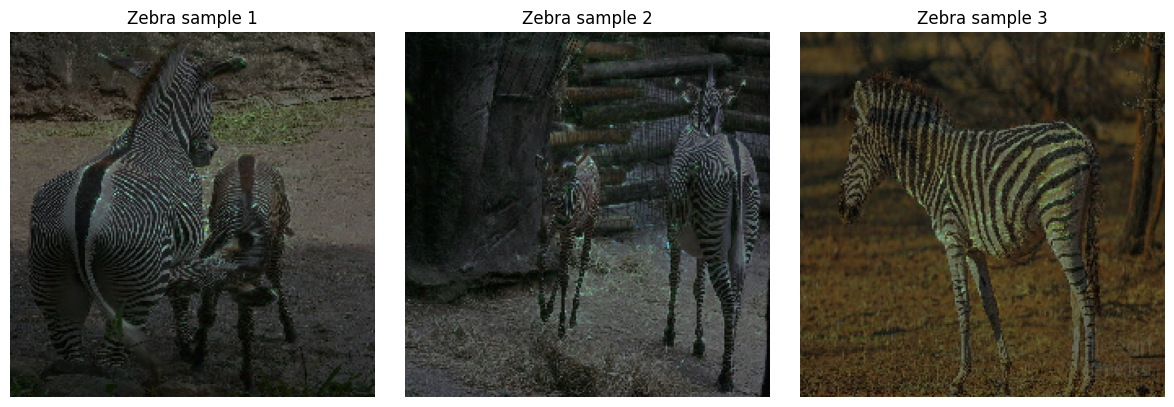

In [25]:
# Cell 6 — Grid of SHAP overlays for a specific class (example: zebras)

import matplotlib.pyplot as plt
import numpy as np

# Select a few zebra samples from the test set
zebra_idx = np.where(y_test_all == classes.index("zebra"))[0][:3]
zebra_imgs = X_test_all[zebra_idx]

# Compute SHAP values for those zebra samples
zebra_shap = run_shap_cnn(model, background, zebra_imgs)

# Plot each zebra image with its SHAP overlay
fig, axes = plt.subplots(1, len(zebra_imgs), figsize=(12, 4))

for i, ax in enumerate(axes):
    shap_map = np.mean(np.abs(zebra_shap[i]), axis=-1)   # collapse RGB channels
    shap_map /= np.max(shap_map)                         # normalize for visibility
    ax.imshow(zebra_imgs[i])
    ax.imshow(shap_map, cmap="inferno", alpha=0.6)
    ax.axis("off")
    ax.set_title(f"Zebra sample {i+1}")

plt.tight_layout()
plt.show()


# CELL 7 — SECTION D: Side‑by‑side model comparison

[MobileNetV2] Computing mean SHAP map...


[ResNet50] Computing mean SHAP map...


[EfficientNetB0] Computing mean SHAP map...


C:\Users\USER-PC\AppData\Local\Temp\ipykernel_1516\3983847060.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


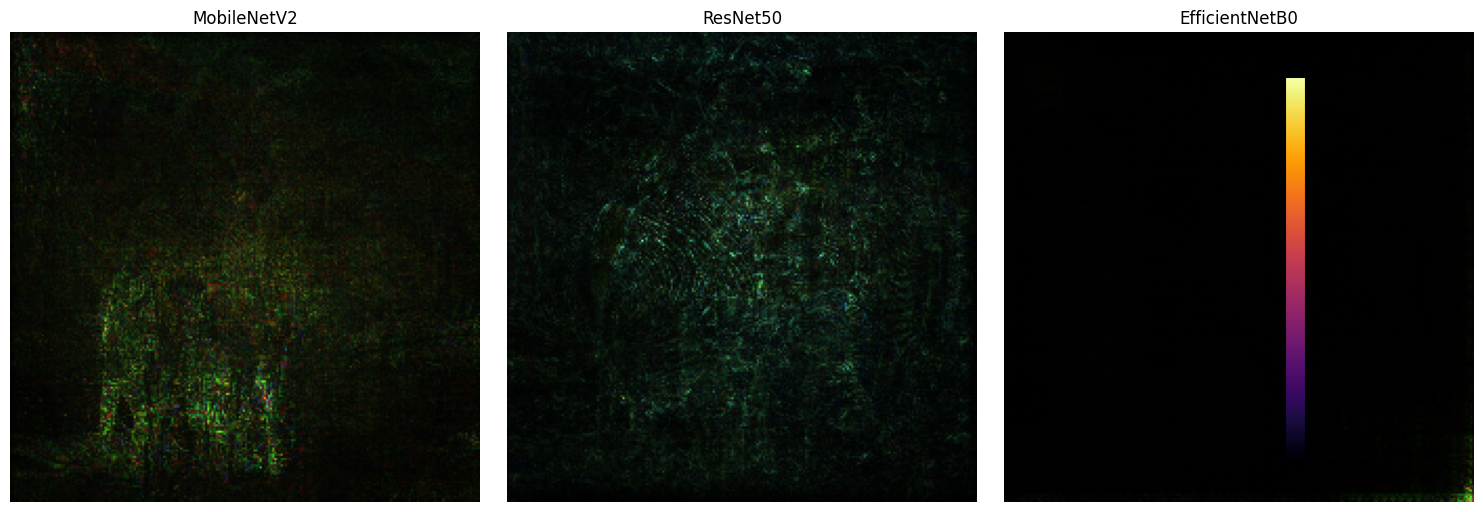

In [27]:
# Cell 7 — Side‑by‑side model comparison with per‑model normalization

fig, axes = plt.subplots(1, len(MODELS), figsize=(15, 5))

mean_maps = {}
for model_name, model_path in MODELS.items():
    if not os.path.exists(model_path):
        print(f"[SKIP] {model_name}: {model_path} not found")
        continue

    print(f"[{model_name}] Computing mean SHAP map...")
    model = tf.keras.models.load_model(model_path)
    shap_vals = run_shap_cnn(model, background, sample_imgs)
    tf.keras.backend.clear_session()

    # Collapse samples + channels → shape (224,224)
    mean_map = np.mean(np.abs(shap_vals), axis=(0, -1))

    # Normalize per model for visibility
    mean_map /= np.max(mean_map)

    mean_maps[model_name] = mean_map

# Plot each model’s normalized mean SHAP
for ax, (model_name, mean_map) in zip(axes, mean_maps.items()):
    im = ax.imshow(mean_map, cmap="inferno", vmin=0, vmax=1)  # fixed scale [0,1]
    ax.set_title(model_name)
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
